Este archivo contiene el preprocesado y división del dataset para un modelos de clasificación para reptiles, actualmente hay 10 clases (chamaleon,crocodile_alligator, frog, gecko, iguana, lizard, salamander, snake, toad, turtle_tortoise). Y la división del dataset es en proporción 70 % para train, 20 % para validation y 10 % para test. 

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import matplotlib.cm as cm
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [16]:
# Verificar la disponibilidad de la GPU y configurar TensorFlow
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU encontrada y configurada.")
    except:
        print("GPU encontrada pero no se pudo configurar el crecimiento de memoria.")
else:
    print("No se encontró GPU, usando CPU.")

GPU encontrada y configurada.


Creamos arrays de rutas y de su respectiva clase para cada imagen

In [17]:
#Cargar las rutas de las imágenes y sus etiquetas
rutas = []
labels = []
data_dir = r"/kaggle/input/datasets/vencerlanz09/reptiles-and-amphibians-image-dataset"

#Recorrer las carpetas y archivos para obtener las rutas y etiquetas
for carpeta in os.listdir(data_dir):
    if os.path.isdir(os.path.join(data_dir, carpeta)):
        for imagen in os.listdir(os.path.join(data_dir, carpeta)):
            rutas.append(os.path.join(data_dir, carpeta, imagen))
            labels.append(carpeta)
            
        
print("Número total de imágenes:", len(rutas))
print("Número total de etiquetas:", len(labels))
print ("Etiquetas únicas:", set(labels))
print("Número de imágenes por etiqueta:", Counter(labels))

Número total de imágenes: 6045
Número total de etiquetas: 6045
Etiquetas únicas: {'Turtle_Tortoise', 'Frog', 'Iguana', 'Snake', 'Toad', 'Crocodile_Alligator', 'Salamander', 'Lizard', 'Gecko', 'Chameleon'}
Número de imágenes por etiqueta: Counter({'Turtle_Tortoise': 1862, 'Crocodile_Alligator': 692, 'Snake': 500, 'Lizard': 500, 'Frog': 499, 'Iguana': 499, 'Toad': 497, 'Salamander': 484, 'Gecko': 302, 'Chameleon': 210})


Tenemos un problema de desbalanceo eso significa que el modelo aprenderá a favorecer las clases con más imagenes y un mal desempeño con clases pequeñas.
Entonces tenemos que ponerle pesos específicos a las clases para que penalice más los errores en las clases pequeñas

In [18]:
#Crear un DataFrame con las rutas y etiquetas
df = pd.DataFrame({"ruta": rutas, "clase": labels})
df.head()  

,ruta,clase
0,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
1,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
2,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
3,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
4,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon


Se decidió dividir dataframes para que el proceso fuera más sencillo y con la ayuda de stratify gerantizamos que haya la misma proporción de cada clase

In [19]:
#Dividir el DataFrame en conjuntos de entrenamiento, validación y prueba
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['clase'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.333, stratify=temp_df['clase'], random_state=42)
print(len(train_df))
print(len(val_df))
print(len(test_df))

4231
1209
605


Una vez dividido todo ahora si procedemos a hacer data augmentation solo para test

In [20]:
#Crear generadores de datos para entrenamiento, validación y prueba

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    zoom_range=0.2,
    horizontal_flip=True,          
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(train_df, x_col='ruta', y_col='clase', target_size=(224, 224), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_dataframe(val_df, x_col='ruta', y_col='clase', target_size=(224, 224), batch_size=32, class_mode='categorical')
test_generator = val_datagen.flow_from_dataframe(test_df, x_col='ruta', y_col='clase', target_size=(224, 224), batch_size=32,shuffle=False, class_mode='categorical')

print(train_generator.class_indices)

Found 4230 validated image filenames belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="ruta". These filename(s) will be ignored.
  warnings.warn(


Found 1209 validated image filenames belonging to 10 classes.
Found 605 validated image filenames belonging to 10 classes.
{'Chameleon': 0, 'Crocodile_Alligator': 1, 'Frog': 2, 'Gecko': 3, 'Iguana': 4, 'Lizard': 5, 'Salamander': 6, 'Snake': 7, 'Toad': 8, 'Turtle_Tortoise': 9}


In [21]:

class_names = list(train_generator.class_indices.keys())
num_classes = len(train_generator.class_indices)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(10, activation='softmax')(x)

modelo = Model(
    inputs=base_model.input,
    outputs=predictions
)
class_weights = sklearn.utils.class_weight.compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weights_dict = dict(enumerate(class_weights))

modelo.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = modelo.fit(train_generator, epochs=30, validation_data=val_generator, verbose=1, class_weight=class_weights_dict)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 78s 511ms/step - accuracy: 0.6589 - loss: 1.1838 - val_accuracy: 0.7916 - val_loss: 0.6409
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 60s 453ms/step - accuracy: 0.7501 - loss: 0.8387 - val_accuracy: 0.7924 - val_loss: 0.6056
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 60s 452ms/step - accuracy: 0.7790 - loss: 0.7398 - val_accuracy: 0.7957 - val_loss: 0.5908
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 60s 450ms/step - accuracy: 0.7974 - loss: 0.6643 - val_accuracy: 0.8081 - val_loss: 0.5846
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 59s 446ms/step - accuracy: 0.8069 - loss: 0.6305 - val_accuracy: 0.8056 - val_loss: 0.5978
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 59s 443ms/step - accuracy: 0.8194 - loss: 0.6009 - val_accuracy: 0.8205 - val_loss: 0.5625
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 59s 447ms/step - accuracy: 0.8229 - loss: 0.5704 - val_accuracy: 0.8238 - val_loss: 0.5760
Epoch 8/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 60s 448ms/step - accuracy: 0.8340 - loss: 0

In [22]:
modelo.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,169,056 (96.01 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,054,230 (4.02 MB)

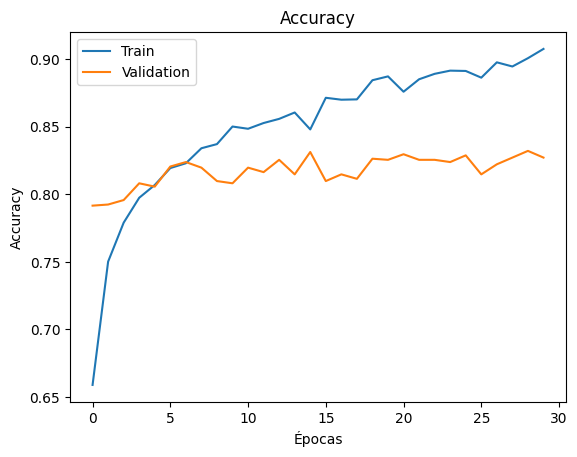

In [23]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

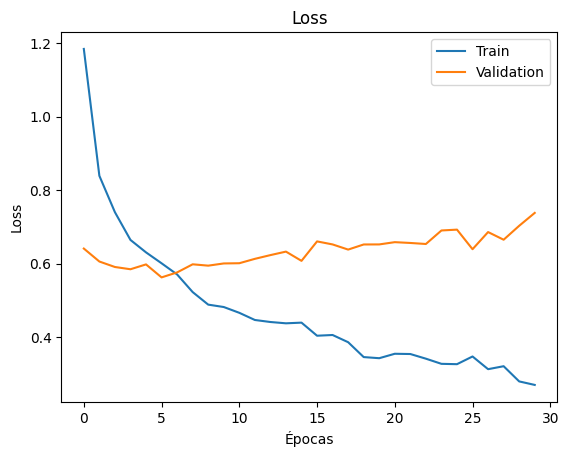

In [24]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [25]:
y_pred = modelo.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

per_class_acc = [report[c]['recall'] for c in class_names]

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 295ms/step
                     precision    recall  f1-score   support

          Chameleon       0.67      0.76      0.71        21
Crocodile_Alligator       0.94      0.97      0.96        69
               Frog       0.70      0.90      0.79        50
              Gecko       0.70      0.53      0.60        30
             Iguana       0.84      0.82      0.83        50
             Lizard       0.63      0.58      0.60        50
         Salamander       0.81      0.92      0.86        48
              Snake       0.92      0.94      0.93        50
               Toad       0.76      0.64      0.70        50
    Turtle_Tortoise       0.98      0.95      0.97       187

           accuracy                           0.85       605
          macro avg       0.80      0.80      0.80       605
       weighted avg       0.85      0.85      0.85       605

Accuracy:  0.8512
Precision: 0.8524
Recall:    0.8512
F1-score:  0.8493


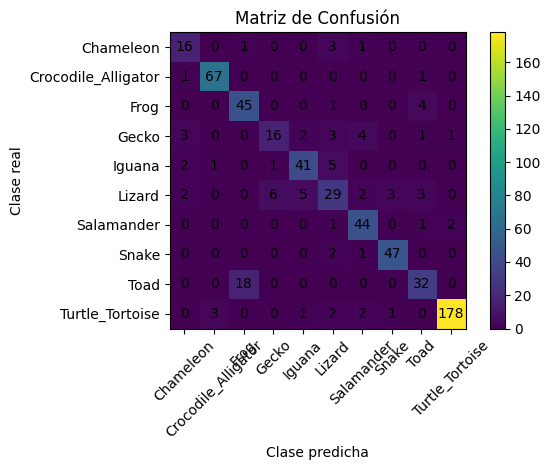

In [26]:
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure()
plt.imshow(conf_matrix)
plt.title("Matriz de Confusión")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, conf_matrix[i, j],
                 ha="center",
                 va="center")

plt.ylabel('Clase real')
plt.xlabel('Clase predicha')
plt.tight_layout()
plt.show()

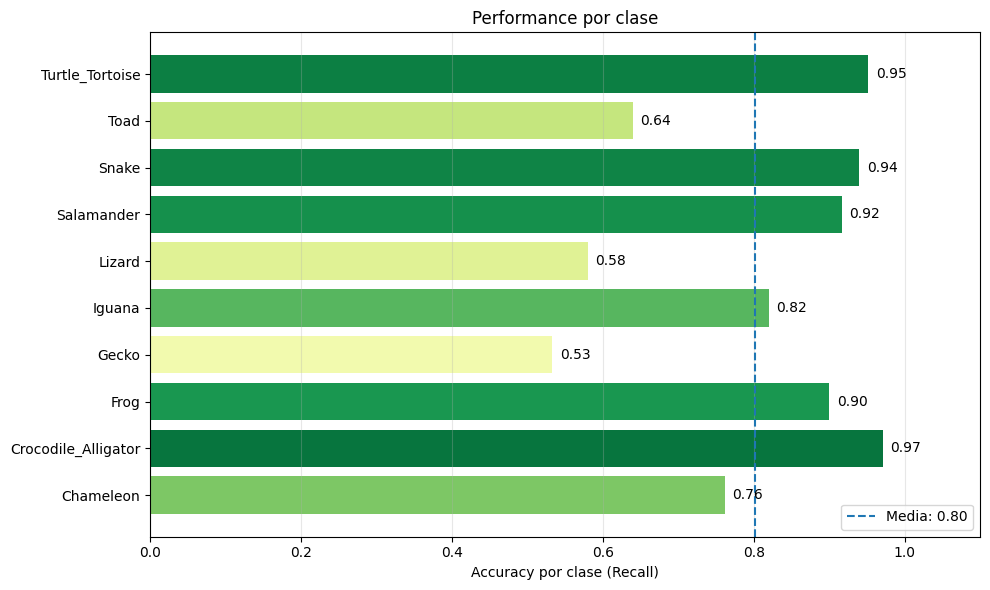

In [27]:

mean_acc = np.mean(per_class_acc)
colors = cm.RdYlGn(per_class_acc)

fig, ax = plt.subplots(figsize=(10, max(5, len(class_names) * 0.6)))

bars = ax.barh(class_names, per_class_acc, color=colors)

ax.axvline(mean_acc, linestyle='--', linewidth=1.5,
           label=f'Media: {mean_acc:.2f}')

ax.set_xlim(0, 1.1)
ax.set_xlabel('Accuracy por clase (Recall)')
ax.set_title('Performance por clase')

ax.legend()
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, per_class_acc):
    ax.text(val + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}',
            va='center')

plt.tight_layout()
plt.show()

In [29]:
modelo.save('modelo_final2.keras')
print("\n modelo_final.keras guardado")


 modelo_final.keras guardado
